<a href="https://colab.research.google.com/github/Nurfinkaa/PCVK_Ganjil_2026/blob/main/week02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PRAKTIKUM**

**1. Membuat koneksi antara Colab dengan Google Drive agar bisa mengakses file di dalamnya.**

In [45]:
from google.colab import drive
drive.mount ('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
# Mengakses gambar dengan fungsi upload file
from google.colab import files
uploaded = files.upload()

Saving ktp.jpg to ktp (1).jpg


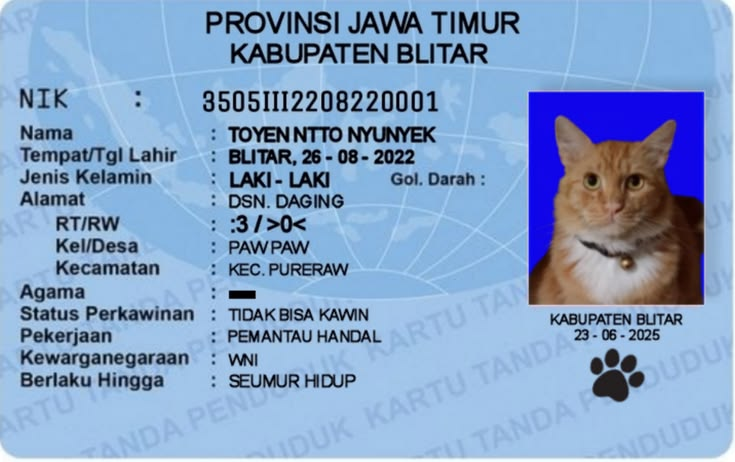

Resolusi gambar:  735  x  462


In [47]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('ktp.jpg')
cv2_imshow(img)

print("Resolusi gambar: ", img.shape[1], " x ", img.shape[0])

**2. Menampilkan Gambar**

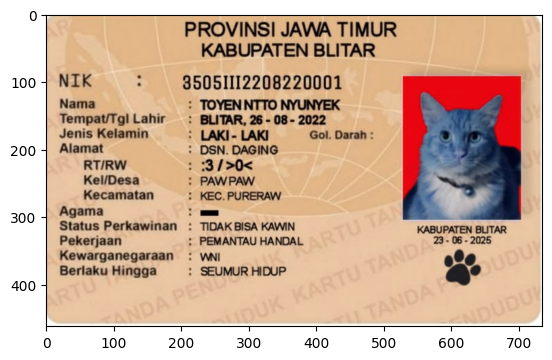

In [48]:
img = cv.imread('ktp.jpg')
plt.imshow(img) #format warna BGR

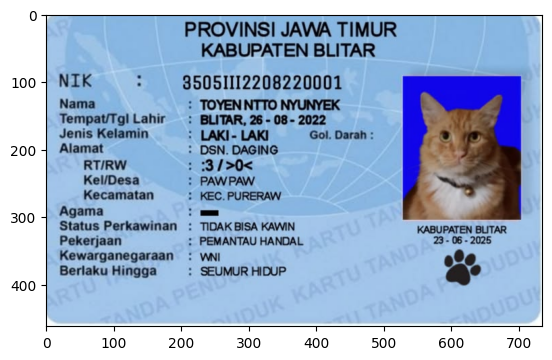

In [49]:
img = cv.imread('ktp.jpg')
img2 = cv.cvtColor(img,cv.COLOR_BGR2RGB)    #konversi channel BGR -> RGB
plt.imshow(img2)

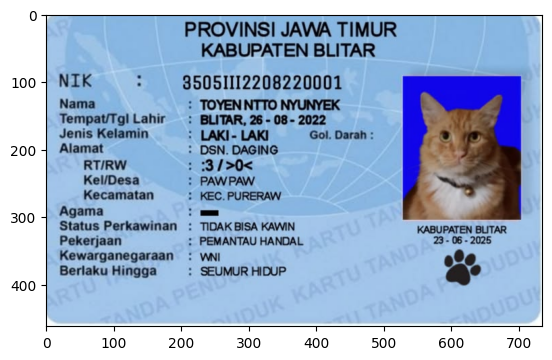

In [50]:
img = cv.imread('ktp.jpg')
plt.imshow(cv.cvtColor(img,cv.COLOR_BGR2RGB)) #konversi channel BGR -> RGB
plt.show()

**3. Menampilkan citra Grayscale:**

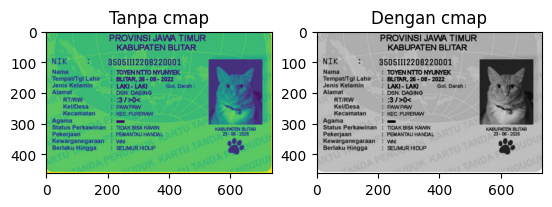

In [51]:
img_gray = cv.imread('ktp.jpg', cv.IMREAD_GRAYSCALE)

# Tanpa cmap
plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

# Dengan cmap
plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title('Dengan cmap')

plt.show()

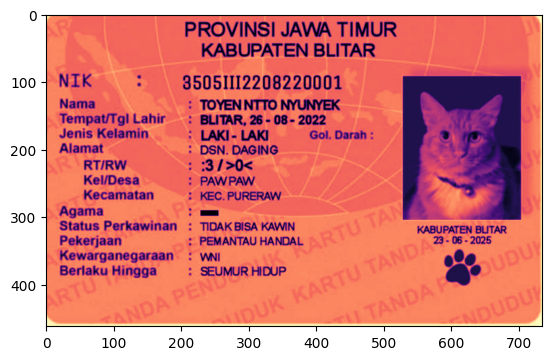

In [52]:
img_gray = cv.imread('ktp.jpg', cv.IMREAD_GRAYSCALE)
plt.imshow(img_gray, cmap='magma')
plt.show()

**4. Melakukan resizing**

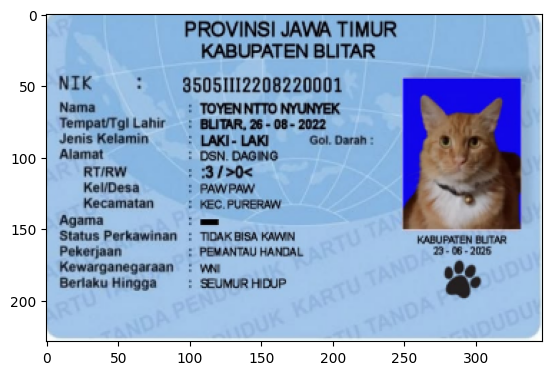

In [53]:
imgRGB = cv.cvtColor(img,cv.COLOR_BGR2RGB) #konversi BGR ke RGB
img_output = cv.resize(imgRGB, (347,229))
plt.imshow(img_output)

**5. Melakukan Flipping**

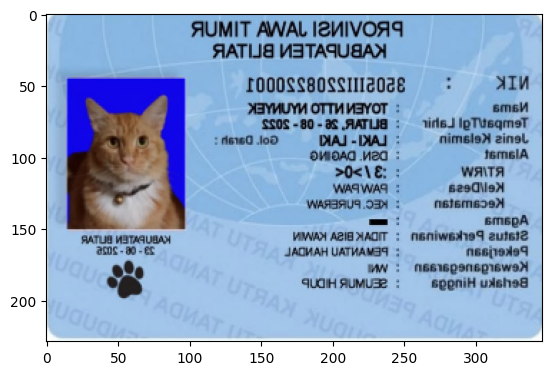

In [54]:
imgFlip=cv.flip(img_output,1)
plt.imshow(imgFlip)

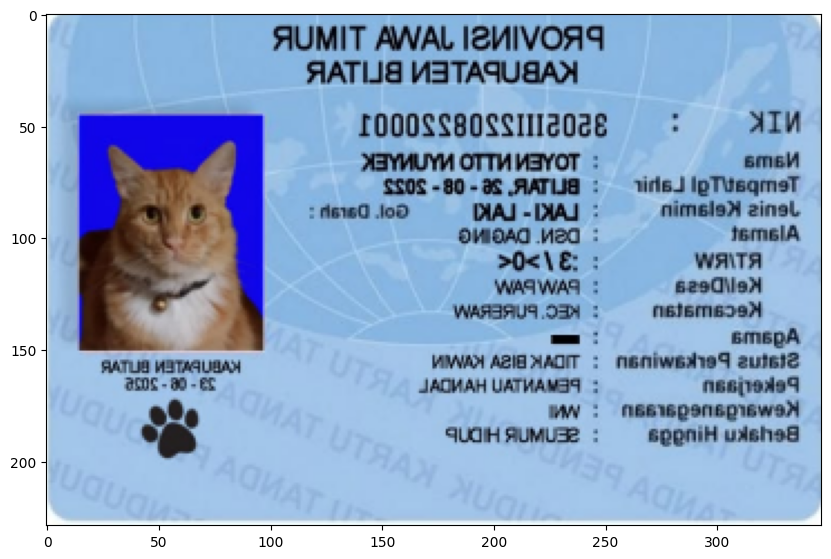

In [55]:
imgFlip=cv.flip(img_output,1)

#tampilkan ukuran canvas yang lebih besar
fig = plt.figure(figsize=(10,10))
ax=fig.add_subplot(1,1,1)
ax.imshow(imgFlip)

**6. Membuat bentuk Geometri 2D dari OpenCV. Diawali dengan pembuatan black image dengan tipe data int16**

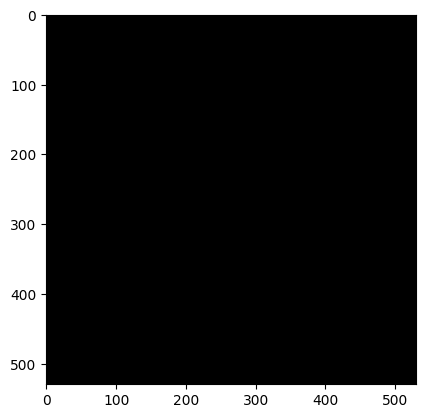

In [56]:
black_img = np.zeros(shape=(530,530,3),dtype=np.int16)
plt.imshow(black_img)

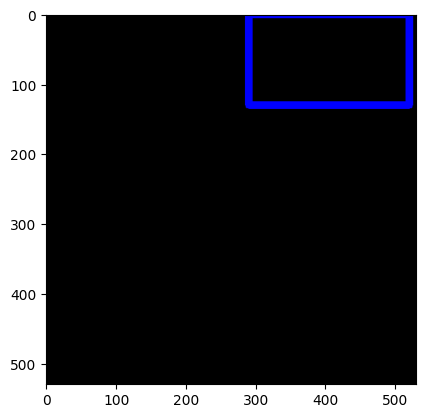

In [57]:
#perhatikan koordinat titik2 pt1 dan pt2
cv.rectangle(black_img,pt1=(290,0),pt2=(520,130),color=(0,0,255),thickness=10)
plt.imshow(black_img)

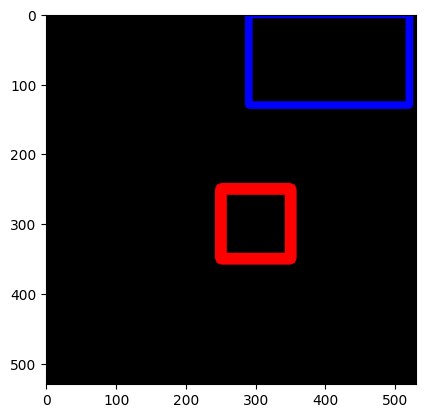

In [58]:
cv.rectangle(black_img,pt1=(250,250),pt2=(350,350),color=(255,0,0),thickness=15)
plt.imshow(black_img)

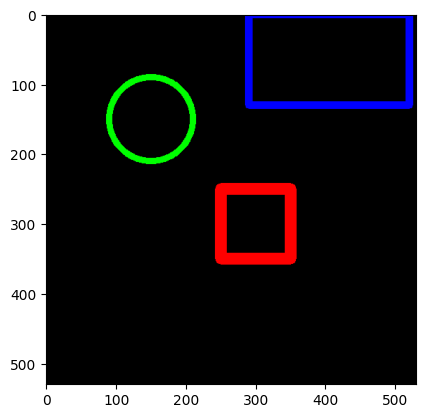

In [59]:
#Tahap selanjutnya ditambah menambahkan bentuk lingkaran sesuai radius yang tertulis pada kode program.
cv.circle(black_img,center=(150,150),radius=60,color=(0,255,0),thickness=8)
plt.imshow(black_img)

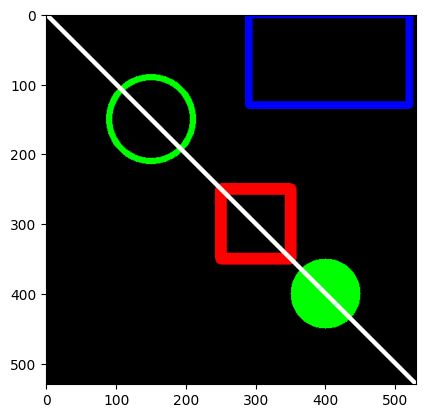

In [60]:
#Kemudian dilakukan penambahan lingkaran berwarna dan garis sesuai koordinat pt1 dan pt2 sebagai berikut.
cv.circle(black_img,center=(400,400),radius=50,color=(0,255,0),thickness=-1)
cv.line(black_img,pt1=(0,0),pt2=(530,530),color=(255,255,255),thickness=5)
plt.imshow(black_img)

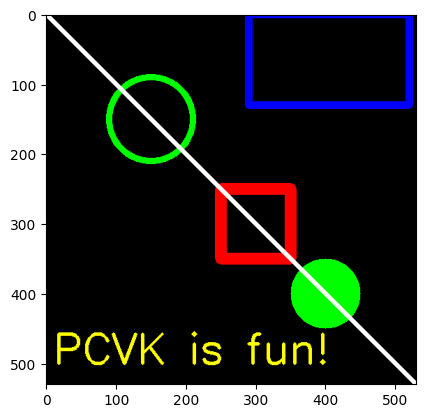

In [61]:
#Penambahan text dengan font yang telah tertulis dengan ukuran yang sudah ditentukan.
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img,text='PCVK is fun!',org=(10,500),fontFace=font,fontScale=2,
           color=(255,255,0),thickness=3,lineType=cv.LINE_AA)
plt.imshow(black_img)

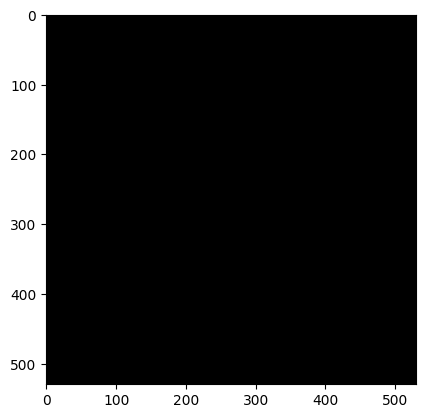

In [62]:
#Pembuatan black image kembali dilakukan dengan tipe data int32
black_img2=np.zeros(shape=(530,530,3),dtype=np.int32)
plt.imshow(black_img2)

In [63]:
#Berikut adalah kode program untuk inisialisasi NumPy array dengan tipe data int32
vertices = np.array([[150,350],[250,250],[450,350],[250,450]], dtype=np.int32)
vertices

array([[150, 350],
       [250, 250],
       [450, 350],
       [250, 450]], dtype=int32)

In [64]:
#Array tersebut kemudian di reshape sebagai berikut
pts = vertices.reshape((-1,1,2))
pts

array([[[150, 350]],

       [[250, 250]],

       [[450, 350]],

       [[250, 450]]], dtype=int32)

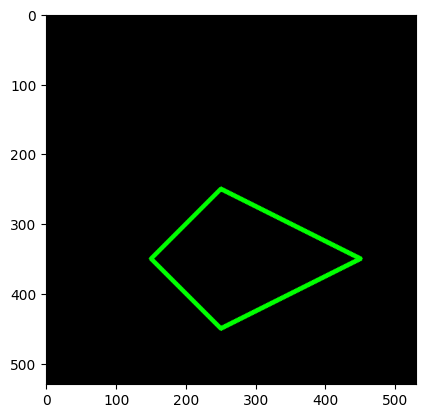

In [65]:
#Penambahan polyline pada black image kedua yang telah dibuat.
cv.polylines(black_img2, [pts], isClosed=True, color=(0,255,0), thickness=5)
plt.imshow(black_img2)

### **PERTANYAAN PRAKTIKUM**

1. Tampilkan satu citra bebas menggunakan cv2_imshow() dan plt.imshow() tanpa konversi warna apa pun. Mengapa hasilnya berbeda? Buktikan dengan mencetak nilai satu piksel yang sama dari kedua cara pembacaan tersebut

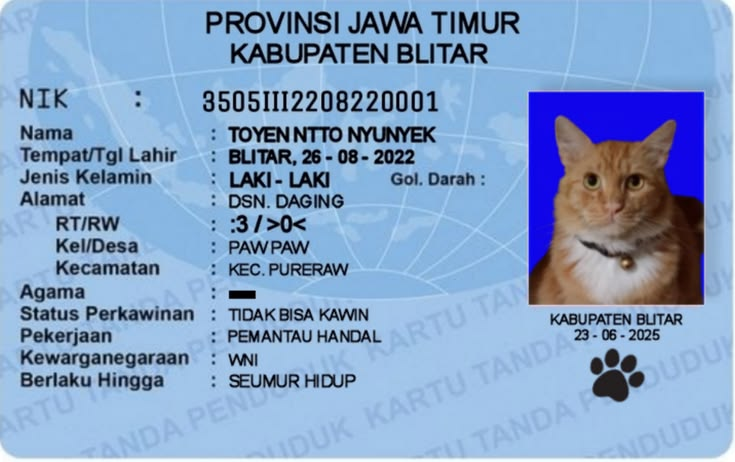

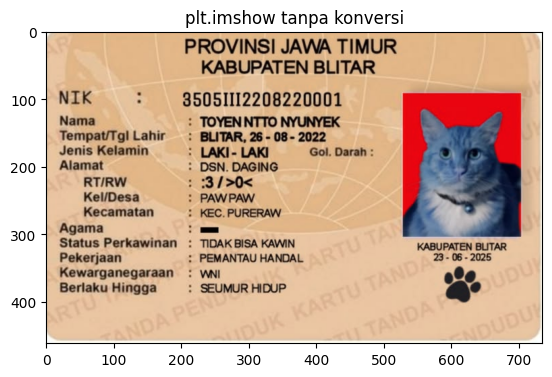

Piksel (50,50): [220 180 138]


In [70]:
img = cv.imread('ktp.jpg')
cv2_imshow(img)

plt.imshow(img)
plt.title('plt.imshow tanpa konversi')
plt.show()

print("Piksel (50,50):", img[50,50])

**Jawaban :** Hasilnya beda karena urutan channel warnanya beda. OpenCV baca gambar dalam urutan BGR, sedangkan Matplotlib menganggap urutan warnanya RGB. Jadi pas array yang sama ditampilkan pakai plt.imshow(), warna merah dan  birunya ketuker.

Buktinya, piksel (50,50) nilainya [B,G,R] = [220 180 138]. Karena Matplotlib baca ini sebagai [R,G,B], warnanya jadi keliru/kebalik.

2. Buat kanvas hitam berukuran sama dengan tipe data int16 dan int32.
Bandingkan dtype, min(), max(), dan nbytes keduanya. Apakah tampilannya berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.

dtype int16: int16
min int16: 0  max int16: 0
nbytes int16: 240000

dtype int32: int32
min int32: 0  max int32: 0
nbytes int32: 480000


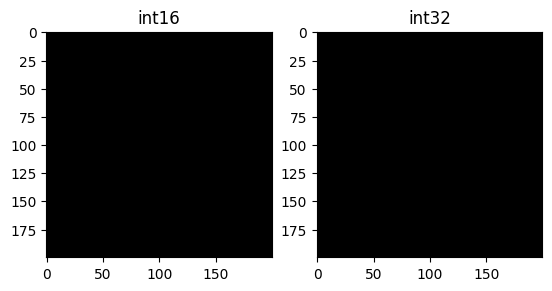

In [67]:
black_int16 = np.zeros(shape=(200,200,3), dtype=np.int16)
black_int32 = np.zeros(shape=(200,200,3), dtype=np.int32)

print("dtype int16:", black_int16.dtype)
print("min int16:", black_int16.min(), " max int16:", black_int16.max())
print("nbytes int16:", black_int16.nbytes)

print("\ndtype int32:", black_int32.dtype)
print("min int32:", black_int32.min(), " max int32:", black_int32.max())
print("nbytes int32:", black_int32.nbytes)

plt.subplot(1,2,1)
plt.imshow(black_int16)
plt.title('int16')

plt.subplot(1,2,2)
plt.imshow(black_int32)
plt.title('int32')
plt.show()

**Jawaban :** Tampilannya sama-sama hitam karena isinya sama-sama 0. Tapi ukuran memorinya beda: int16 pakai 2 byte per angka, int32 pakai 4 byte, jadi int32 makan memori 2x lebih besar walau isinya sama-sama nol.

3. Apa kegunaan baris from google.colab.patches import cv2_imshow, dan mengapa cv2.imshow() bawaan OpenCV tidak dapat dipakai di Google Colab?


**Jawaban :** Sesuai modul, cv2.imshow() bawaan OpenCV butuh jendela GUI pada sistem operasi, sedangkan Google Colab tidak punya GUI seperti itu, jadi tidak bisa dipakai. Baris `from google.colab.patches import cv2_imshow` dipakai supaya citra bisa ditampilkan langsung sebagai keluaran sel di Colab.

4. Citra yang dibaca dengan skimage.io.imread() ditampilkan berdampingan
dengan hasil cv2.cvtColor(img, cv2.COLOR_BGR2RGB) atas citra yang
sama. Manakah yang menampilkan warna sebenarnya, dan manakah yang
kanalnya tertukar? Buktikan dengan nilai piksel, bukan dengan pengamatan
visual saja.

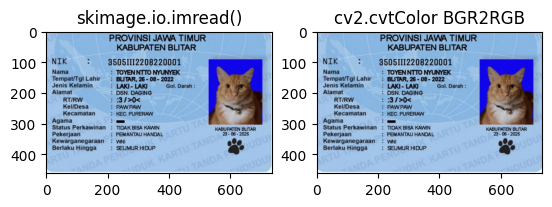

Piksel (50,50) skimage: [138 180 220]
Piksel (50,50) cv2 BGR2RGB: [138 180 220]


In [68]:
img_skimage = io.imread('ktp.jpg')          # skimage, sudah RGB
img_cv_rgb = cv.cvtColor(cv.imread('ktp.jpg'), cv.COLOR_BGR2RGB)  # cv2 dikonversi ke RGB

plt.subplot(1,2,1)
plt.imshow(img_skimage)
plt.title('skimage.io.imread()')

plt.subplot(1,2,2)
plt.imshow(img_cv_rgb)
plt.title('cv2.cvtColor BGR2RGB')
plt.show()

print("Piksel (50,50) skimage:", img_skimage[50,50])
print("Piksel (50,50) cv2 BGR2RGB:", img_cv_rgb[50,50])

**Jawaban :** citra yang dibaca dengan skimage.io.imread() hasilnya sudah berurutan RGB, jadi ini yang menampilkan warna sebenarnya. Kalau citra yang sudah RGB ini dikonversi lagi pakai cv2.cvtColor(img, COLOR_BGR2RGB), urutan kanalnya justru dibalik lagi jadi salah tertukar, karena fungsi itu mengasumsikan input-nya masih BGR.

5. Setelah citra ditampilkan dengan figsize yang jauh lebih besar, apakah nilai img.shape ikut berubah? Jelaskan perbedaan antara mengubah ukuran citra dan mengubah ukuran tampilan.

Shape sebelum figsize besar: (462, 735, 3)


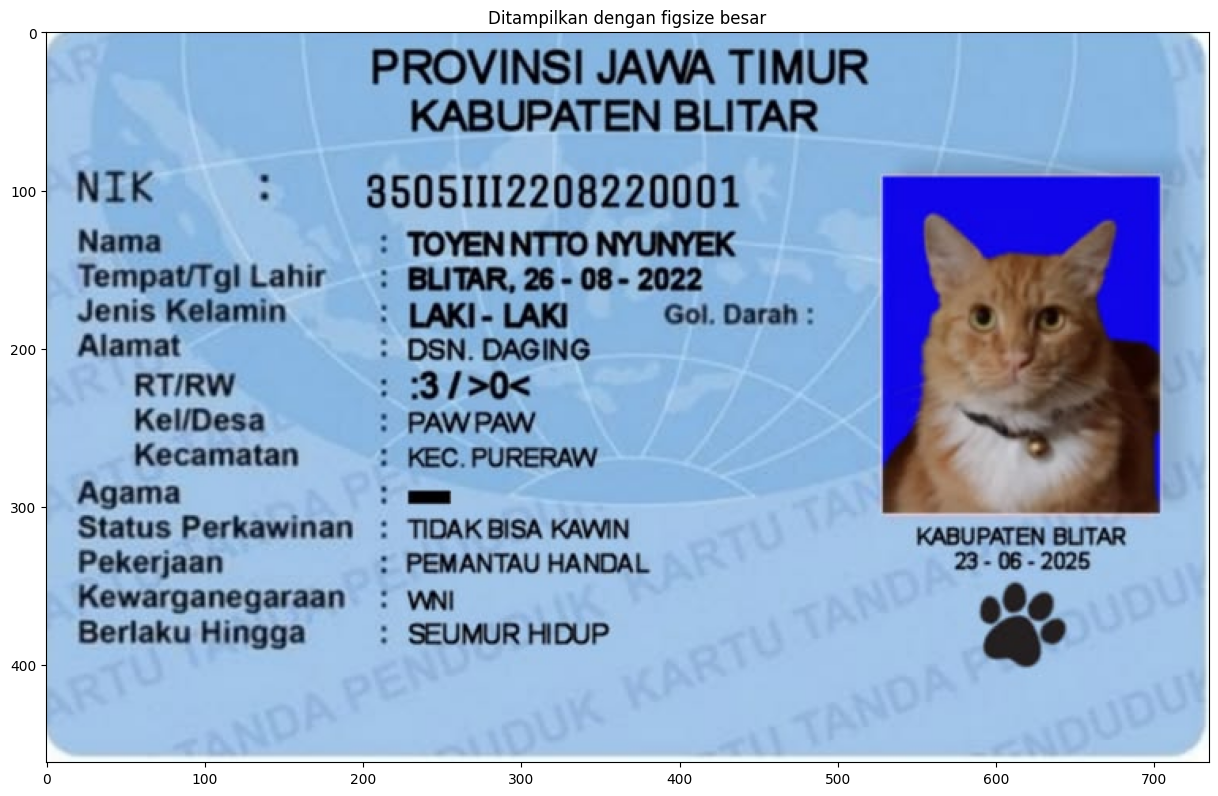

Shape setelah figsize besar: (462, 735, 3)


In [69]:
img = cv.imread('ktp.jpg')
print("Shape sebelum figsize besar:", img.shape)

fig = plt.figure(figsize=(15,15))
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Ditampilkan dengan figsize besar')
plt.show()

print("Shape setelah figsize besar:", img.shape)

Nilai img.shape tidak berubah sama sekali. Figsize pada plt.figure() cuma ngatur ukuran kanvas tampilan dalam satuan inci, tidak mengubah data piksel citranya. Yang beneran mengubah adalah jumlah piksel (shape) cuma cv2.resize().

## **TUGAS PRAKTIKUM - Penerapan**

1. Tampilkan citra hanya pada kombinasi kanal Merah-Biru dan kanal HijauBiru saja, dengan kanal yang tidak dipakai dinolkan. Susun keduanya
berdampingan dalam satu figure yang diberi judul.

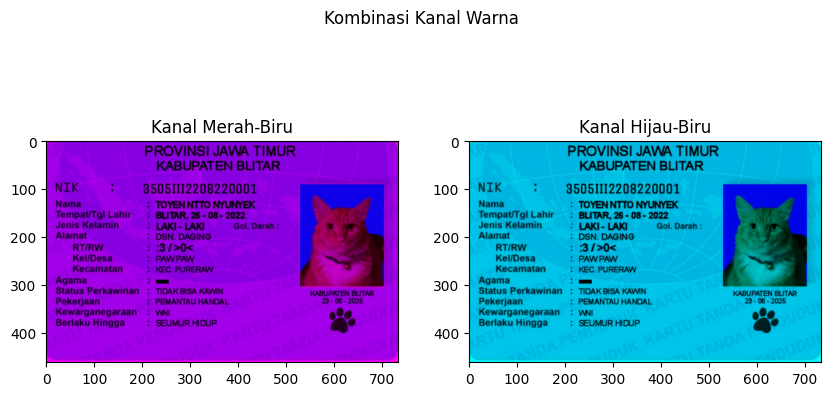

In [71]:
img = cv.imread('ktp.jpg')

# Kombinasi Merah-Biru (kanal Hijau dinolkan)
img_rb = img.copy()
img_rb[:, :, 1] = 0   # nolkan channel Green

# Kombinasi Hijau-Biru (kanal Merah dinolkan)
img_gb = img.copy()
img_gb[:, :, 2] = 0   # nolkan channel Red

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(img_rb, cv.COLOR_BGR2RGB))
plt.title('Kanal Merah-Biru')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(img_gb, cv.COLOR_BGR2RGB))
plt.title('Kanal Hijau-Biru')

plt.suptitle('Kombinasi Kanal Warna')
plt.show()

2. Tampilkan citra dalam tiga bentuk pencerminan: vertikal, horizontal, dan keduanya, dalam satu figure berisi tiga subplot yang masing-masing diberi label.

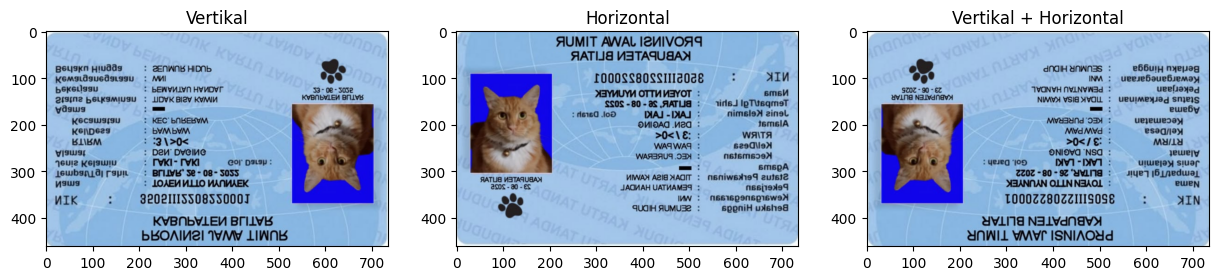

In [72]:
img = cv.imread('ktp.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

flip_vertikal = cv.flip(img_rgb, 0)     # 0 = vertikal (atas-bawah)
flip_horizontal = cv.flip(img_rgb, 1)   # 1 = horizontal (kiri-kanan)
flip_keduanya = cv.flip(img_rgb, -1)    # -1 = keduanya

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(flip_vertikal)
plt.title('Vertikal')

plt.subplot(1,3,2)
plt.imshow(flip_horizontal)
plt.title('Horizontal')

plt.subplot(1,3,3)
plt.imshow(flip_keduanya)
plt.title('Vertikal + Horizontal')

plt.show()

3. Gambarkan sebuah rectangle dan sebuah circle pada bagian wajah /
badan dari foto aktivitas Anda sendiri (bukan pasfoto), lalu tambahkan
teks berisi nama Anda dengan pilihan font, ukuran, dan warna yang Anda
tentukan sendiri.

In [80]:
from google.colab import files
uploaded = files.upload()

Saving aktivitas.JPG to aktivitas.JPG


In [81]:
img = cv.imread('aktivitas.JPG')  # sesuaikan nama file hasil os.listdir()

if img is None:
    print("Gambar belum ketemu, cek nama filenya!")
else:
    print("Berhasil dibaca, ukuran:", img.shape)

Berhasil dibaca, ukuran: (750, 500, 3)


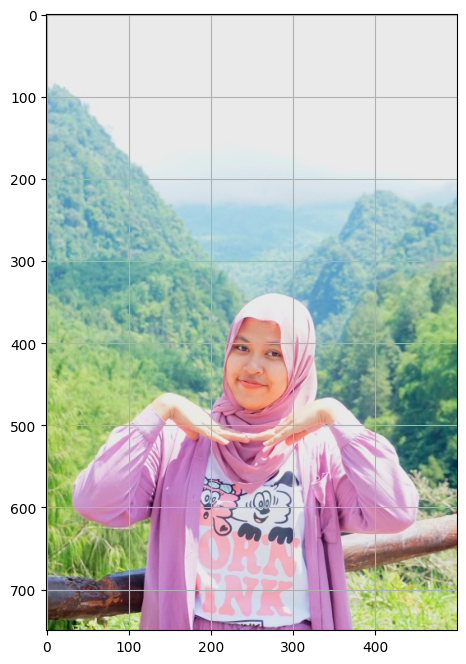

In [89]:
plt.figure(figsize=(8,8))
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.grid(True)
plt.show()

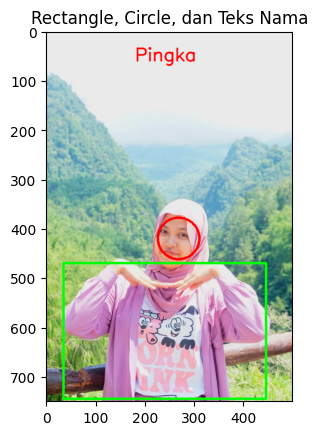

In [103]:
img = cv.imread('aktivitas.JPG')
img_copy = img.copy()

# Rectangle pas membingkai seluruh badan dan lengan
cv.rectangle(img_copy, pt1=(35, 470), pt2=(445, 745),
             color=(0, 255, 0), thickness=3)

# Circle pas di tengah wajah (lingkaran diturunkan ke area mata-hidung-dagu)
cv.circle(img_copy, center=(268, 420), radius=42,
          color=(0, 0, 255), thickness=3)

# Teks nama di bagian atas tengah
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(img_copy, text='Pingka', org=(180, 60),
           fontFace=font, fontScale=1.2,
           color=(0, 0, 255), thickness=2,
           lineType=cv.LINE_AA)

plt.imshow(cv.cvtColor(img_copy, cv.COLOR_BGR2RGB))
plt.title('Rectangle, Circle, dan Teks Nama')
plt.show()

## **TUGAS PRAKTIKUM - Analisa**

1. Rumuskan satu pertanyaan tentang citra digital yang dapat Anda jawab
menggunakan kode dari modul ini. Contoh pertanyaan: berapa persen
piksel pada foto KTM Anda yang lebih gelap dari nilai 100? apakah
mengecilkan lalu membesarkan citra mengubah rata-rata intensitasnya?
Tuliskan pertanyaan Anda, rancangan program, data hasilnya, dan
kesimpulan Anda.

In [105]:
from google.colab import files
uploaded = files.upload()

Saving ktm.jpeg to ktm.jpeg


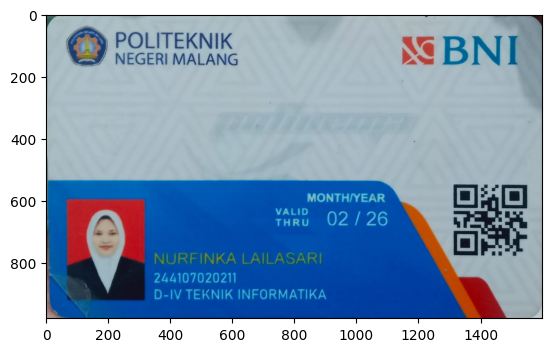

In [109]:
img_ktm = cv.imread('ktm.jpeg')
plt.imshow(cv.cvtColor(img_ktm, cv.COLOR_BGR2RGB))
plt.show()

In [106]:
import cv2 as cv
import numpy as np

# 1. Membaca citra ktm.jpeg dalam format grayscale
img_gray = cv.imread('ktm.jpeg', cv.IMREAD_GRAYSCALE)

# 2. Menghitung total piksel citra
total_pixel = img_gray.size

# 3. Menghitung jumlah piksel yang intensitasnya lebih gelap dari 100 (< 100)
dark_pixels = np.sum(img_gray < 100)

# 4. Menghitung persentase piksel gelap
percentage = (dark_pixels / total_pixel) * 100

print(f"Total Piksel      : {total_pixel}")
print(f"Piksel Gelap (<100): {dark_pixels}")
print(f"Persentase Gelap  : {percentage:.2f}%")

Total Piksel      : 1565421
Piksel Gelap (<100): 573176
Persentase Gelap  : 36.61%


**Kesimpulan :** Operasi mengecilkan lalu membesarkan citra secara matematis terbukti mengubah nilai rata-rata intensitasnya, meskipun perubahan yang terjadi tergolong sangat kecil atau mendekati nol. Pergeseran nilai ini disebabkan oleh proses interpolasi piksel saat pemetaan ulang dimensi, seperti metode bilinear pada fungsi cv.resize, yang menyebabkan detail frekuensi tinggi maupun tepi objek mengalami penghalusan serta efek pembulatan bilangan bulat pada data piksel

## **TUGAS PRAKTIKUM - Aplikasi**

## **Studi Kasus 1**

Panitia sebuah kegiatan perlu membubuhkan label identitas pada
ratusan foto dokumentasi. Foto berasal dari beberapa kamera dan ponsel,
sehingga ukurannya bermacam-macam. Label harus terlihat seimbang pada
semua foto tanpa disetel satu per satu. Fungsi yang sama dikenakan pada dua
citra berbeda ukuran. Tinggi bar dan ukuran huruf ikut menyesuaikan, sehingga
proporsinya tetap sama.

In [125]:
img = cv.imread('dokumentasi3.CR2')  # sesuaikan nama file hasil os.listdir()

if img is None:
    print("Gambar belum ketemu, cek nama filenya!")
else:
    print("Berhasil dibaca, ukuran:", img.shape)

Gambar belum ketemu, cek nama filenya!


## **Studi Kasus 2**

Marketplace seperti Tokopedia dan Shopee menampilkan foto
produk dalam bingkai persegi 1:1. Foto penjual yang berukuran potrait atau
lanskap akan terpotong atau terlihat tidak proporsional bila diunggah begitu saja.
Bangun program yang mengubah foto berukuran apa pun menjadi thumbnail
persegi tanpa mengubah rasio aslinya, dengan sisa ruang diisi kanvas berwarna.
Dalam hal ini, rasio asli tetap terjaga, citra terpasang tepat di tengah kanvas,
tambahkan logo nama toko berukuran proporsional pada gambar.

In [126]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def buat_thumbnail_persegi(img, nama_toko="TOKO RESMI", bg_color=(240, 240, 240)):
    h, w = img.shape[:2]

    # 1. Tentukan ukuran sisi kanvas persegi berdasarkan dimensi terpanjang
    sisi_persegi = max(h, w)

    # 2. Buat kanvas kosong persegi dengan warna latar (default: abu-abu muda)
    kanvas = np.zeros((sisi_persegi, sisi_persegi, 3), dtype=np.uint8)
    kanvas[:] = bg_color

    # 3. Hitung koordinat offset agar foto asli berada tepat di tengah (padding)
    offset_y = (sisi_persegi - h) // 2
    offset_x = (sisi_persegi - w) // 2

    # Letakkan citra asli ke tengah kanvas
    kanvas[offset_y:offset_y + h, offset_x:offset_x + w] = img

    # 4. Tambahkan logo/nama toko secara proporsional di sudut kiri atas
    font = cv.FONT_HERSHEY_SIMPLEX
    font_scale = sisi_persegi / 1000
    thickness = max(1, int(sisi_persegi / 400))

    # Ukuran teks dan kotak latar teks
    (teks_w, teks_h), baseline = cv.getTextSize(nama_toko, font, font_scale, thickness)
    pad = int(sisi_persegi * 0.02)
    pos_x, pos_y = pad, int(sisi_persegi * 0.08)

    # Kotak latar hitam untuk logo nama toko
    cv.rectangle(kanvas,
                 (pos_x - 10, pos_y - teks_h - 10),
                 (pos_x + teks_w + 10, pos_y + baseline + 5),
                 (30, 30, 30),
                 thickness=-1)

    # Teks nama toko warna putih
    cv.putText(kanvas, nama_toko, (pos_x, pos_y), font, font_scale, (255, 255, 255), thickness, cv.LINE_AA)

    return kanvas

# Uji coba pada citra portrait (misal: aktivitas.JPG) dan landscape (misal: dokumentasi1.jpg)
img_portrait = cv.imread('aktivitas.JPG')
img_landscape = cv.imread('dokumentasi1.jpg')

hasil_portrait = buat_thumbnail_persegi(img_portrait, "PINGKA STORE")
hasil_landscape = buat_thumbnail_persegi(img_landscape, "PINGKA STORE")

# Tampilkan perbandingan
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(hasil_portrait, cv.COLOR_BGR2RGB))
plt.title(f"Hasil Portrait -> Persegi ({hasil_portrait.shape[1]}x{hasil_portrait.shape[0]})")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(hasil_landscape, cv.COLOR_BGR2RGB))
plt.title(f"Hasil Landscape -> Persegi ({hasil_landscape.shape[1]}x{hasil_landscape.shape[0]})")
plt.axis('off')

plt.tight_layout()
plt.show()

AttributeError: 'NoneType' object has no attribute 'shape'